<a href="https://colab.research.google.com/github/ashadool26/Comprehensive-Data-Analysis-and-Modeling-of-Mobile-Phone-Sales/blob/main/Comprehensive_Data_Analysis_and_Modeling_of_Mobile_Phone_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

# Load Dataset

In [5]:
df= pd.read_csv("/content/top 120 best-selling mobile phones.csv")

# Dispaly First  Five Rows

In [6]:
df.head()

,Rank,Manufacturer,Model,Form Factor,Smartphone?,Year,Units Sold (million )
0,1,Nokia,1100,Bar,False,2003,250.0
1,2,Nokia,1110,Bar,False,2005,247.5
2,3,Apple,iPhone 6 & 6 Plus,Touchscreen,True,2014,222.4
3,4,Nokia,105 Series,Bar,False,2013,200.0
4,5,Apple,iPhone 6S & 6S Plus,Touchscreen,True,2015,174.1


In [7]:
df

,Rank,Manufacturer,Model,Form Factor,Smartphone?,Year,Units Sold (million )
0,1,Nokia,1100,Bar,False,2003,250.0
1,2,Nokia,1110,Bar,False,2005,247.5
2,3,Apple,iPhone 6 & 6 Plus,Touchscreen,True,2014,222.4
3,4,Nokia,105 Series,Bar,False,2013,200.0
4,5,Apple,iPhone 6S & 6S Plus,Touchscreen,True,2015,174.1
...,...,...,...,...,...,...,...
115,116,Samsung,Samsung Galaxy A55,Touchscreen,True,2024,2.7
116,117,Samsung,Samsung Galaxy S24,Touchscreen,True,2024,2.4
117,118,Samsung,Samsung Galaxy A15 4G,Touchscreen,True,2023,2.2
118,119,Google,Pixel & Pixel XL,Touchscreen,True,2016,2.1


# checking Missing values

In [9]:
df.isnull().sum()

,0
Rank,0
Manufacturer,0
Model,0
Form Factor,0
Smartphone?,0
Year,0
Units Sold (million ),0


# If missing values exist, fill or drop


In [10]:
df = df.dropna()

# summary Statistics

In [11]:
df.describe()

,Rank,Year,Units Sold (million )
count,120.000000,120.000000,120.000000
mean,60.500000,2012.758333,48.050000
std,34.785054,6.590030,58.044835
min,1.000000,1996.000000,2.000000
25%,30.750000,2007.000000,10.000000
50%,60.500000,2013.000000,22.050000
75%,90.250000,2019.000000,60.000000
max,120.000000,2024.000000,250.000000


# Histogram of unit sold

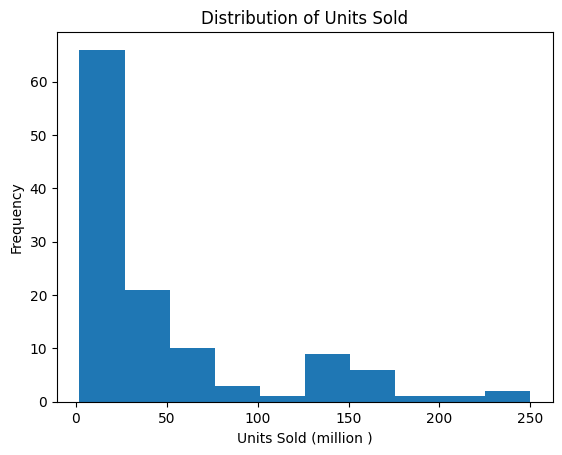

In [16]:
plt.figure()
plt.hist(df["Units Sold (million )"])
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold (million )")
plt.ylabel("Frequency")
plt.show()

# Trend of Units Sold Over Years

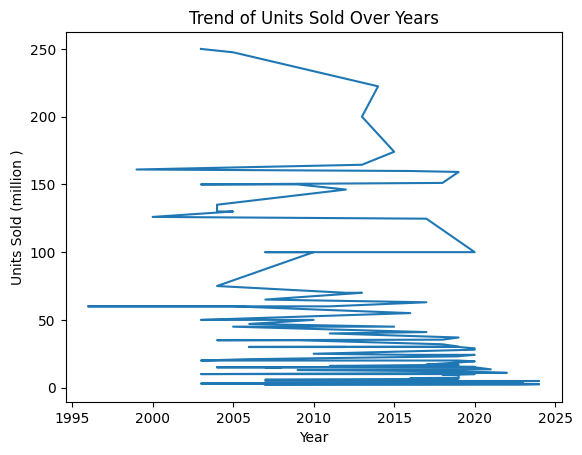

In [18]:
plt.figure()
plt.plot(df["Year"], df["Units Sold (million )"])
plt.title("Trend of Units Sold Over Years")
plt.xlabel("Year")
plt.ylabel("Units Sold (million )")
plt.show()

# T-Test (Smartphone vs Non-Smartphone)

In [20]:
smartphones = df[df["Smartphone?"] == True]["Units Sold (million )"]
non_smartphones = df[df["Smartphone?"] == False]["Units Sold (million )"]

t_stat, p_value = stats.ttest_ind(smartphones, non_smartphones)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.3881329319072755
P-value: 0.0009570509480181121


# Correlation Matrix & Heatmap

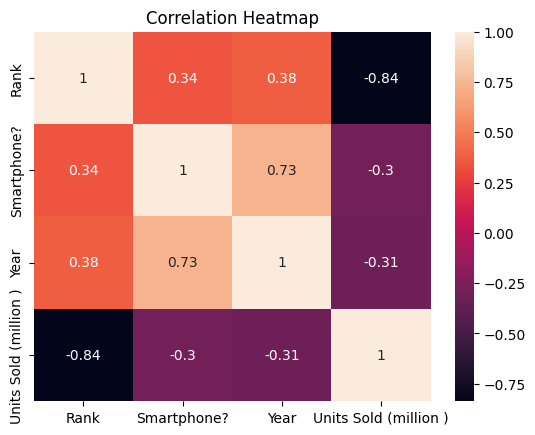

In [21]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Total Units Sold by Manufacturer

In [23]:
manufacturer_sales = df.groupby("Manufacturer")["Units Sold (million )"].sum()
manufacturer_sales

,Units Sold (million )
Manufacturer,
Apple,1669.3
Google,2.1
HTC,16.0
Huawei,113.8
LG,92.0
LeTV,3.0
Motorola,323.0
Nokia,2374.5
Oppo,16.7


# Top 5 Manufacturers

In [24]:
top5 = manufacturer_sales.sort_values(ascending=False).head(5)
top5

,Units Sold (million )
Manufacturer,
Nokia,2374.5
Apple,1669.3
Samsung,994.5
Motorola,323.0
Huawei,113.8


# Pivot Table (Year × Manufacturer)

In [26]:
pivot_table = pd.pivot_table(
    df,
    values="Units Sold (million )",
    index="Year",
    columns="Manufacturer",
    aggfunc="sum")

pivot_table

Manufacturer,Apple,Google,HTC,Huawei,LG,LeTV,Motorola,Nokia,Oppo,Palm,Research in Motion (RIM),Samsung,Sony Ericsson,Xiaomi
Year,,,,,,,,,,,,,,
1996,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161.0,NaN,NaN,NaN,NaN,NaN,NaN
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN,NaN,NaN
2003,NaN,NaN,NaN,NaN,NaN,NaN,60.0,473.0,NaN,NaN,NaN,10.0,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,130.0,295.0,NaN,NaN,NaN,NaN,15.0,NaN
2005,NaN,NaN,NaN,NaN,NaN,NaN,60.0,422.5,NaN,NaN,NaN,NaN,15.0,NaN
2006,NaN,NaN,NaN,NaN,21.0,NaN,NaN,77.0,NaN,NaN,15.0,30.0,15.0,NaN
2007,6.0,NaN,NaN,NaN,5.0,NaN,NaN,340.0,NaN,2.0,NaN,NaN,NaN,NaN
2008,NaN,NaN,NaN,NaN,40.0,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN


# Top 10 Best-Selling Models (Bar Chart)

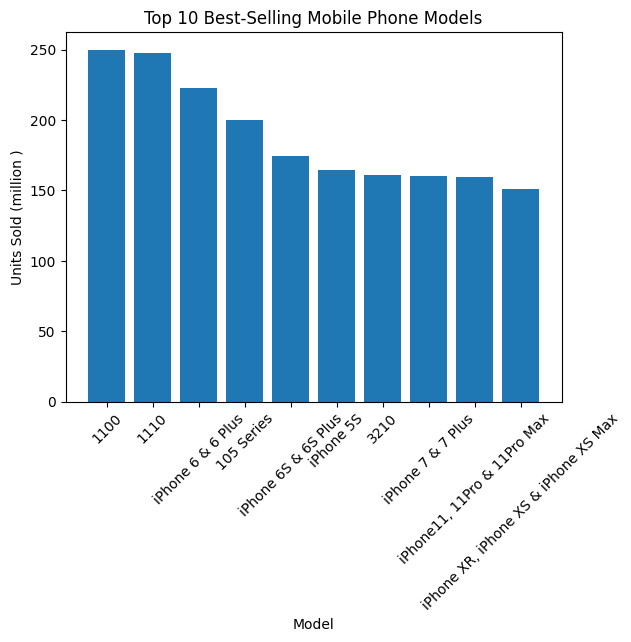

In [27]:
top10_models = df.sort_values(
    by="Units Sold (million )",
    ascending=False
).head(10)

plt.figure()
plt.bar(top10_models["Model"], top10_models["Units Sold (million )"])
plt.xticks(rotation=45)
plt.title("Top 10 Best-Selling Mobile Phone Models")
plt.xlabel("Model")
plt.ylabel("Units Sold (million )")
plt.show()

# Boxplot (Smartphone vs Non-Smartphone)

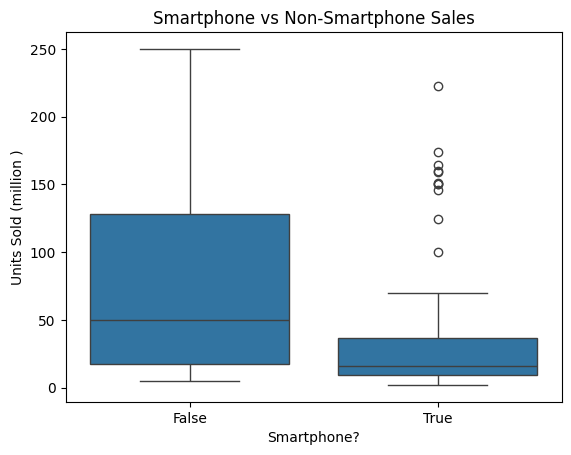

In [29]:
plt.figure()
sns.boxplot(x="Smartphone?", y="Units Sold (million )", data=df)
plt.title("Smartphone vs Non-Smartphone Sales")
plt.show()

# Linear Regression Model

In [35]:
X = df[["Year"]]
y = df["Units Sold (million )"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

**Model Evaluation**

In [36]:
r2 = r2_score(y, predictions)
mse = mean_squared_error(y, predictions)

print("R-squared:", r2)
print("Mean Squared Error:", mse)

R-squared: 0.09892892513491547
Mean Squared Error: 3010.5921462581923


# Regression Line Plot

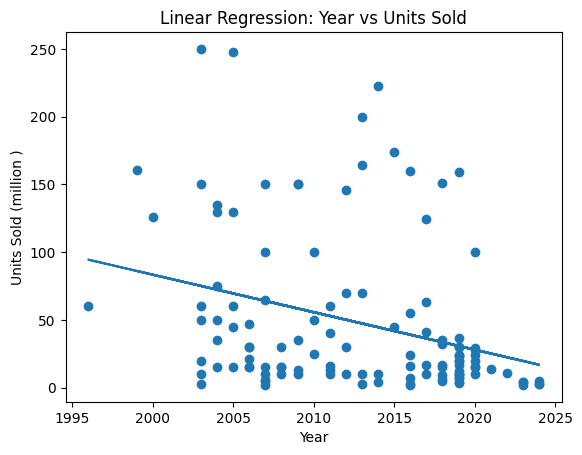

In [38]:
plt.figure()
plt.scatter(df["Year"], df["Units Sold (million )"])
plt.plot(df["Year"], predictions)
plt.title("Linear Regression: Year vs Units Sold")
plt.xlabel("Year")
plt.ylabel("Units Sold (million )")
plt.show()

**THE END**

